## Outcome devaluation and habit expression

The goal of this project is to explore the consequences of the interaction between context uncertainty and context-specific action priors in a set of simulation studies, probably supported by experimental analysis. Main idea is that increased contextual uncertainty generally experienced by users can interact with highly precise context-specific action priors to bring about unexplained phenomena in addiction such behaviour expression despite devaluation.

Firstly we look at **outcome devaluation and habit expression**

It is an open question **whether strong action priors can maintain responding even when outcome value decreases, especially when context inference is uncertain**. Here we want to show the boiling frog effect. Slow contextual change favours within context updating rather than inferring new context. So ideally we want to have a drug context with strong action priors and a slowly changing environment. Agent does not infer new context but updates original consumption one leading to maladaptive behaviour despite devaluation.

-	We were talking about something like this during writing Sarah’s 2021 paper. The thought was to change the reward probability slowly during the context so that there is repetition and the agent stays within context. In a reward change simulation, the originally prefered action slowly becomes punishing. So the consumption action no longer **leads to reward** and the nonconsumption action leads to reward instead. In a devaluation simulation the posterior over contexts at t=2 will be driven by the prior over contexts, the policy surprise and the outcome surprise. Or in other words a balance between what context the agent expected to be in, how surprised the agent is by its own action, and how surprised the agent is by the outcome given its goals and that it executed policy one. Last term should vary with reward contingencies and utility.
-	Is it possible to somehow parameterize how certain an agent infers contexts? And for context inference would the precision of the action prior in the ‘use’ context make it more certain that this context is inferred? (this would directly touch the point of interaction between action prior and context - **yes**). Intuitively: because the agent is uncertain about what to infer as a context, he goes for the context where at least it knows what to do with certainty (stays in control)
-	SUGGESTION
	- Initialize agent with 2 contexts and 2 posible actions. 
	- First context has a strong action preference for action 1 which it believes is very rewarding (v=0.9). Correspondingly, action 2 is non-rewarding. 
	- Then vary true reward rate as a random walk  with some reward as a random walk with different parameters. Vary utility as a random walk with different parameters. I can either directly initialize action preference 
	- Plot habitual tendency (trial at which abstinence action is executed). 
	- Trial at which context posterior goes  for context 1 drops below 0.5

Maybe first simply do devaluation change after having learned contingencies for context 1 and look if this pushes into context 2. Then look at two learned contexts and whether changing utility will push agent into inferring presence of context 1 again with and without habit.


## Classes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
import jsonpickle
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)


## Functions

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
import jsonpickle
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 prior_cs = None,
				 prior_color_cue = None,
				 learn_cues = False
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations

  
		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility
		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])

		self.learn_cues = learn_cues

		if learn_cues:
			self.prior_cs_counts = np.zeros([self.TAU, self.T] + list(prior_cs.shape))
			self.prior_cs_counts[0,:] = prior_cs[None,:,:]
			self.prior_cs = np.zeros(self.prior_cs_counts.shape)
			self.prior_cs[0,:] = (prior_cs / prior_cs.sum(axis=0)[None,:])[None,:]


			self.prior_color_cue_counts = np.zeros([self.TAU, self.T] + list(prior_color_cue.shape))
			self.prior_color_cue_counts[0,:] = prior_color_cue[None,:,:]
			self.prior_color_cue = np.zeros(self.prior_color_cue_counts.shape)
			self.prior_color_cue[0,:] = (prior_color_cue / prior_color_cue.sum(axis=0)[None,:])[None,:]
			
		else:
			self.prior_cs = np.zeros([self.TAU, self.T] + list(prior_cs.shape))
			self.prior_cs[:,:,:,:] = (prior_cs / prior_cs.sum(axis=0))[None,None,:,:]
			
			
			self.prior_color_cue = np.zeros([self.TAU, self.T] + list(prior_color_cue.shape))
			self.prior_color_cue[:,:,:,:] = (prior_color_cue / prior_color_cue.sum(axis=0))[None,None,:,:]

		self.cs_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.background_color_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility

		# print(tau,t,self.utility)
		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context, cs, background_color):
	
		# print(tau,t)
		# context-specific policy likelihood
		
		cs_surprise = self.ln(self.prior_cs[tau,t,cs]) 
		color_surprise = self.ln(self.prior_color_cue[tau,t,background_color])
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


		else:
			outcome_surprise = np.array([0]*self.nc)
			policy_entropy   = np.array([0]*self.nc)
			policy_surprise  = np.array([0]*self.nc)

		
		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)  + color_surprise #+ cs_surprise
						   
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))


		if self.debug:
			print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			print('outcome_surprise')
			print(outcome_surprise.round(3))
			print('policy_entropy')
			print(policy_entropy.round(3))
			print('policy_surprise')
			print(policy_surprise.round(3))
			print('cs_surprise')
			print(cs_surprise.round(3))
			print('color_surprise')
			print(color_surprise.round(3))
			print('prior_context')
			print(self.ln(prior_context).round(3))
			print('posterior context')
			print(posterior_context.round(3))
		
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		self.cs_surprise[tau,t] = cs_surprise
		self.background_color_surprise[tau,t] = color_surprise

		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_cs(self, t, tau, cs, posterior_context):
		
		alphas = self.prior_cs_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[cs,:] += posterior_context
		self.prior_cs_counts[tau+1] = alphas_prime[None,:,:]

		posterior_predictive_cs = self.digamma_approximation(alphas_prime)
		
		self.prior_cs[tau+1] = posterior_predictive_cs[None,:,:]


	def update_beliefs_prior_color_cue(self, t, tau, background_color, posterior_context):
		
		alphas = self.prior_color_cue_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[background_color,:] += posterior_context
		self.prior_color_cue_counts[tau+1] = alphas_prime[None,:,:]
		posterior_predictive_color_cue = self.digamma_approximation(alphas_prime)
		self.prior_color_cue[tau+1] = posterior_predictive_color_cue[None,:,:]


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[pol_ind,:] += posterior_context
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation, cs, background_color):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context, cs, background_color)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)

			if self.learn_cues:
				self.update_beliefs_prior_cs(t, tau, cs, posterior_context)
				self.update_beliefs_prior_color_cue(t, tau, background_color, posterior_context)

		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau,t,:,:,k].round(3))

				if self.learn_cues:
					print(f"\ncs counts:")
					print(f"cs: {cs}")
					print(f"\n{self.prior_cs_counts[tau,t].round(3)}")

					print(f"\nbackground color counts:")
					print(f"color: {background_color}")
					print(f"\n{self.prior_color_cue_counts[tau,t].round(3)}")


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				 cs_context_mapping = None,
				 color_cue_context_mapping = None):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)
		self.cs = np.zeros([TAU,T], dtype=int)
		self.background_color = np.zeros([TAU,T], dtype=int)
		
		self.color_cue_context_mapping = color_cue_context_mapping
		self.cs_context_mapping = cs_context_mapping
		self.ncs = cs_context_mapping.shape[0]
		self.nbc = color_cue_context_mapping.shape[0]

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no


		if training_protocol is None:
			self.training_protocol = np.repeat(np.arange(self.number_reward_regimes),\
											   np.ceil(self.TAU/self.number_reward_regimes))[:self.TAU]
		else:
			self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state):
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		return self.rewards[tau,t]
	
	def sample_background_color(self, t, tau):
		self.background_color[tau,:] = np.random.choice(self.nbc, p=self.color_cue_context_mapping[:, self.training_protocol[tau]])
		return self.background_color[tau,t]
	
	def sample_cs(self, t, tau):
		# print(self.cs_context_mapping)
		# print(self.training_protocol)
		# print()
		self.cs[tau,:] = np.random.choice(self.ncs, p=self.cs_context_mapping[:, self.training_protocol[tau]])
		return self.cs[tau,t]

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():


	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr


	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]


	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
					cs = self.environment.sample_cs(t, tau)
					background_color = self.environment.sample_background_color(t, tau)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)
					cs = self.environment.cs[tau,t]
					background_color = self.environment.background_color[tau,t]

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)


				
				self.agent.update_beliefs(t, tau, state, reward, action, observation, cs, background_color)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0




#####



sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


def plot_reward_regime(k_range, switch=100, TAU=400, start=0.9, stop=0.1):

	# function that ranges between start and stop decays with a varying rate k
	logistic = lambda x, k: stop - (start-stop) / (np.exp(switch*k) - 1) + (np.exp(switch*k) + 1) / (np.exp(switch*k) - 1)*(start-stop)/(1+np.exp(k*(x-switch)))

	for k in k_range:
		x = np.arange(0,switch*2,1)
		p_win = logistic(x,k)
		
		plt.plot(np.arange(TAU), p_win, label=f"decay rate k: {k}")
		plt.xlabel("trial")
		plt.ylabel(r"reward probability bandit 1")
		
	plt.legend()


def run_simulation(h=1000, trials_per_context = [2,2], TAU=4, rep=1, na=2, nb=2, ns=3, no=3, nr=3, nc=2, T=2, approx_pred_pol = True, approx_pred_rew = True,
				   utility = np.array([0.98,0.01, 0.01]), Rho = None, debug=False, context_volatility=0.98, contexts=None, learn_cues=True, prior_color_cue=None):
	
	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(nb+1)]*nb).transpose([1,2,0])
	state_transition_matrix[:,-1,:] = np.eye(nb+1)[:,:-1]

	state_transition_matrix = np.zeros([ns,ns,na])


	for b in range(nb):
		state_transition_matrix[b,:,b] = 1
	
	'''          define p(o_t|s_t)            '''
	
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.05, size = counts_prior_rewards.shape)
	
	# bias = 1
	# init_counts = np.ones([nr,nb+1])
	# init_counts[0,0] = bias
	# init_counts[1,1:] = bias
	# init_counts[:,-1] = [1,1,100]
	# counts_prior_rewards[:,:,0] = init_counts


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.9] + [1-0.9]*(nc-1))

	p = 0.9
	q = 1-p


	'''       define prior over light CS and background color cue        '''
	if learn_cues:
		prior_light_CS = np.ones([2,nc]) + np.random.uniform(low=0,high=0.05, size = [2,nc])
		if prior_color_cue is None:
			prior_color_cue = np.ones([3,nc]) + np.random.uniform(low=0,high=0.05, size = [3,nc])
		# print(prior_color_cue)
	else:
		pass
		prior_light_CS = np.ones([2,nc]) + (np.eye(2)[:,[0]*nc])*20
		# if not prior_color_cue is None: 
		# 	prior_color_cue = np.ones([3,nc]) + (np.eye(3)[:,[0,1,2]])*np.array([3,3,0])[None,:]
	
	# print(f"==>> prior_color_cue: {prior_color_cue}")


	'''       define observation context mapping                          '''
	
	cs_map = np.eye(2)[:,[0,0,0]] 
	color_cue_map = np.eye(3)

	'''   p(c_t|c_t-1)'''
	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env training protocol    '''

	training_protocol = []
	for phase in range(nc):
		training_protocol += [phase]*trials_per_context[phase]
	training_protocol = np.array(training_protocol)

	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:		
		p_win = 0.9
		Rho = np.zeros([nr,ns,TAU])
		trials = np.insert(np.cumsum(trials_per_context), 0,0)

		training = np.array([[1-p_win, p_win  , 0],\
							 [p_win  , 1-p_win, 0],\
							 [0      , 0      , 1]])
		p_win = 1
		extinction = np.array([[p_win, 1-p_win  , 0],\
							   [1-p_win  , p_win, 0],\
							   [0      , 0      , 1]])
		
		contingencies = [training, extinction, extinction]
		
		for t in range(1, trials.size):
			Rho[:,:,trials[t-1]:trials[t]] = contingencies[t-1][:,:,None]
		
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		sns.heatmap(Rho[:,:,0],annot=True,ax=axes[0], cbar=False)
		sns.heatmap(Rho[:,:,-1],annot=True,ax=axes[1], cbar=False)
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = nb,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						cs_context_mapping = cs_map,
						color_cue_context_mapping = color_cue_map,
						no=no)

	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			prior_cs = prior_light_CS,
			prior_color_cue = prior_color_cue,
			learn_cues = learn_cues
			)

	world = World(agent, env)

	world.simulate_experiment()

	return world 


def run_belief_update(actions = None, rewards=None, observations=None, h=1000, training_protocol = [0,0,1,1], TAU=4, rep=1, na=2, nb=2, ns=3, no=3, nr=3, nc=2, T=2, approx_pred_pol = True, approx_pred_rew = True,
				   utility = np.array([0.98,0.01, 0.01]), Rho = None, utility_decay_rate = None, context_volatility=0.98):
	
	"""
	Function runs belief updates given some generated rewards, observations and behaviour
	
	"""

	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(nb+1)]*nb).transpose([1,2,0])
	state_transition_matrix[:,-1,:] = np.eye(nb+1)[:,:-1]
	
	'''          define p(o_t|s_t)            '''
	
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.5, size = counts_prior_rewards.shape)
	
	bias = 1
	init_counts = np.ones([nr,nb+1])
	init_counts[0,0] = bias
	init_counts[1,1:] = bias
	init_counts[:,-1] = [1,1,100]
	counts_prior_rewards[:,:,0] = init_counts

	# if approx_pred_rew:
	# 	prior_rewards = scp.digamma(counts_prior_rewards) - scp.digamma(counts_prior_rewards.sum(axis=0)) 
	# 	prior_rewards = scp.softmax(prior_rewards, axis=0)
	# else:
	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h

	# if approx_pred_pol:
	# 	prior_policies = scp.softmax(scp.digamma(counts_prior_policies) - scp.digamma(counts_prior_policies.sum(axis=0)))
	# else:
	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.9] + [1-0.9]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(np.isclose(context_transition_matrix.sum(axis=0), 1)))

	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:
		p = 0.9
		q = 1-p
		bandits = np.arange(nb)
		Rho = np.ones([nr,ns,len(bandits)])*q

		for context,b in enumerate(bandits):
			Rho[0,b,context] = p
			Rho[1,np.arange(nb+1) != b,context] = p

		Rho[-1,:] = 0
		Rho[:,-1] = 0
		Rho[-1,-1] = 1

	Rho = Rho[:,:,training_protocol]
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			sns.heatmap(Rho[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = nb,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=no)


	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix
			)

	world = World(agent, env)

	world.simulate_belief_update(actions, rewards, observations)

	return world 


def run_cue_reactivity_simulations(learn_cues=False, hs=np.array([1,10,1000]), context_volatility=0.99, utility=np.array([0.025,0.95,0.025]), trials_per_context=[10,5,5],\
								na=2, nr=3, nc=2, nsims=1, TAU=20, T=2, debug=False, contexts=["A","B","C"], sim_name=None, prior_color_cue=None, block_size=20):


	nb = na
	ns = nb + 1
	no = ns
	npi = na**(T-1)
	nc = len(contexts)


	"""agent params"""
	# hs = np.array(hs)
	utilities = np.array([utility])
	agent_instance = np.arange(nsims)
	context_volatilities = np.array([context_volatility])

	"""environment params"""
	trials_per_context = np.array([trials_per_context])

	## construct list of simulations
	parameter_combinations = product(agent_instance, hs, utilities, trials_per_context, context_volatilities)
	sim_params = []

	for p in parameter_combinations:
		# sim specific params
		pars = {}
		pars["rep"] = p[0]
		pars["h"] = p[1]
		pars["utility"] = p[2]
		pars["trials_per_context"] = p[3]
		pars["context_volatility"] = p[4]
		# pars["Rho"] = p[5]

		## global params
		pars["TAU"] = TAU
		pars["na"] = na
		pars["nb"] =  nb
		pars["ns"] = ns
		pars["no"] = no
		pars["nr"] =  nr
		pars["nc"] = len(contexts)
		pars["contexts"] = contexts 
		pars["T"] = T
		pars["debug"] = debug
		pars["learn_cues"] = learn_cues
		pars["prior_color_cue"] = prior_color_cue
		# pars["block_size"] = block_size
		# pars["reward_decay_rate"] = p[5][1]
		sim_params.append(pars)



	### run simulations
	# print(sim_params)
	print(f"simulations to run: {len(sim_params)}")

	df = { col : [] for col in ["run","habitual_tendency",\
								"utility_0"	,"utility_1","utility_2", "context_volatility",\
								# "context_a","context_b","context_c","context_d", "context_func",\
								# "policy_a","policy_b","policy_c","policy_d","policy_func", "dkl_c1", "dkl_c2",\
								"q_context", "q_policy",\
								# "se_context_a", "se_context_b", "se_context_c", "se_context_d",\
								"habit_c1", "habit_c2", "habit_c3", "preference_a2_c1", "preference_a2_c2", "preference_a2_c3", "failed"]}#,"threshold_c",, "inflection_trial"]} #, "habit_strength_context", "habit_strength_action"
	long_dfs = []
	for pi, p in enumerate(sim_params):
		if pi% 250 == 0:
			print(f"just finished sim {pi}")
		
		world = run_simulation(**p)
		agent = world.agent
		
		# Create long format dataframe
		run_arr = np.full(TAU * T, p["rep"])
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		reward_arr = world.environment.rewards.flatten()
		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, p["h"])
		context_volatility_arr = np.full(TAU * T, p["context_volatility"])
		utility_0_arr = np.full(TAU * T, p["utility"][0])
		utility_1_arr = np.full(TAU * T, p["utility"][1])
		utility_2_arr = np.full(TAU * T, p["utility"][2])
		n_blocks = TAU // block_size
		# print(n_blocks)
		# print(block_size)
		block_arr = np.arange(n_blocks).repeat(block_size * T)
		# print(block_arr.size)
		sim_arr = np.full(TAU*T,pi)
		true_context = world.environment.training_protocol.repeat(2)

		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surp_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		inferred_context = np.argmax(agent.posterior_context[:,0,:],axis=1)
		nic = np.unique(inferred_context).size
		best_fit = 0
		best_mapping = []
		if pi == 2:
			a = 0
		if nic == 2:
			failed = True
			best_mapping = np.unique(inferred_context)
			best_mapping = np.append(best_mapping, np.setdiff1d(np.arange(nc), best_mapping)[0])
		else:
			failed = False
			for i in range(100):
				mapping = np.random.permutation(nc)
				fit = (mapping[inferred_context] == world.environment.training_protocol).sum()
				if fit > best_fit:
					best_fit = fit
					best_mapping = mapping

		# for c in range(nc):
		for ci, c in enumerate(best_mapping):
			context_post_arr[f"posterior_context_c{ci}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{ci}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{ci}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surp_arr[f"outcome_surprise_c{ci}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(npi):
				reward_prior_arr[f"reward_s{pi}_c{ci}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{ci}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{ci}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{ci}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"block": block_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"utility_0": utility_0_arr,
			"utility_1": utility_1_arr,
			"utility_2": utility_2_arr,
			"sim":sim_arr,
			"true_context":true_context,
			"failed": np.array([failed]).repeat(TAU*T),
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surp_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		long_df = pd.DataFrame(long_df_dict)
		long_dfs.append(long_df)


		### calculate H
		# sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
		# exponential = lambda t, b, c, d: d + np.exp(b*(t-c))
		
		# fitting_functions = [sigmoid, exponential]
		# t = np.arange(1,TAU+1)

		q_context = agent.posterior_context[:,1,1]
		q_action =  np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0])[:,1]
		

		# try:
		# 	context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,trials_per_context,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)
		# 	context_func = 0.


		# except RuntimeError:

		# 	try:
		# 		context_pcov = np.eye(4)
		# 		context_params = np.zeros(4)
		# 		context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,trials_per_context,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
		# 		context_params[0] = 1
		# 		context_func = 1

		# 	except RuntimeError:
		# 		context_params[:] = np.nan
		# 		context_func = np.nan

		# try:
		# 	# posterior_pol = (w.agent.posterior_policies[:,0,1]*w.agent.posterior_context[:,0]).sum(axis=1)[10:]
		# 	# plt.figure()
		# 	# plt.ylim((0,1))


		# 	policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,trials_per_context,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
		# 	policy_func = 0

		# except RuntimeError:

		# 	try:
		# 		policy_params = np.zeros(4)
		# 		policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,trials_per_context,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
		# 		policy_params[0] = 1.
		# 		policy_func = 1


		# 	except RuntimeError:
		# 		policy_params[:] = np.nan
		# 		policy_func = np.nan

		
		"""Short format dataframe"""

		# se = np.sqrt(np.diag(context_pcov))
		# q_rewards = agent.prior_rewards[-1,-1]
		# p_rewards = world.environment.Rho[:,:,[0,-1]]+1e-10
		# dkl = (q_rewards * np.log(q_rewards/p_rewards)).sum(axis=0).mean(axis=0)

		preference_action = long_df.query("t==1").groupby(by="true_context")["observation"].sum() / p["trials_per_context"]
		
		df["preference_a2_c1"].append(preference_action.iloc[0])
		df["preference_a2_c2"].append(preference_action.iloc[1])
		df["preference_a2_c3"].append(preference_action.iloc[2])
		df["habit_c1"].append(np.argmax(agent.prior_policies[-1,-1], axis=0)[0])
		df["habit_c2"].append(np.argmax(agent.prior_policies[-1,-1], axis=0)[1])
		df["habit_c3"].append(np.argmax(agent.prior_policies[-1,-1], axis=0)[2])
		df["failed"].append(failed)
		df["run"].append(p["rep"])
		df["habitual_tendency"].append(1/p["h"])
		# df["context_a"].append(context_params[0])
		# df["context_b"].append(context_params[1])
		# df["context_c"].append(context_params[2] - TAU // 2)
		# df["context_d"].append(context_params[3])
		# df["context_func"].append(context_func)
		# df["policy_a"].append(policy_params[0])
		# df["policy_b"].append(policy_params[1])
		# df["policy_c"].append(policy_params[2] - TAU // 2)
		# df["policy_d"].append(policy_params[3])
		# df["policy_func"].append(policy_func)

		df["q_context"].append(q_context)
		# df["dkl_c1"].append(dkl[0])
		# df["dkl_c2"].append(dkl[1])
		# df["se_context_a"].append(se[0])
		# df["se_context_b"].append(se[1])
		# df["se_context_c"].append(se[2])
		# df["se_context_d"].append(se[3])
		df["q_policy"].append(q_action)
		df["utility_0"] = p["utility"][0]
		df["utility_1"] = p["utility"][1]
		df["utility_2"] = p["utility"][2]
		df["context_volatility"].append(p["context_volatility"])


	if sim_name is not None:
		name=sim_name
	else:
		name = f"data_cue_reactivity_{TAU}_util{utilities[0][1]}_context{context_volatilities[0]}"

	df = pd.DataFrame(df)
	print(utility, context_volatility)
	df.to_csv(name +".csv", index=False)

	long_df = pd.concat(long_dfs)
	long_df.to_csv(name + "_long.csv", index=False)
	print(name)

	return df, long_df, name


def save_excluded(df):
	for ri, row in df.iterrows():
		if row["excluded"]:
			# fitting_functions = [sigmoid, exponential]
			fig, axes = plt.subplots(1,2,figsize=(10,4), sharey=True)
			for fi,fitted_posterior in enumerate(["context","policy"]):
				pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
				q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
				axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
				axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
				axes[fi].set_ylim((0,1.05))
				axes[fi].grid()
				try:
					func_ind = (int(row[f"{fitted_posterior}_func"]))
					x = np.arange(TAU+1)
					axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
					par_vals = row[pars].copy()
					par_vals[2] += TAU // 2
					y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
					axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
					axes[fi].legend(loc="center left")
					axes[fi].set_title(row[pars].round(2).to_numpy())
				except:
					pass
				fig.savefig(f"img//deval_context_volatility{context_volatility}_util{row['utility_decay_rate']}_h{row['habitual_tendency']}_ind{ri}.png")
				plt.close()


def save_missed_failures(df):
	for ri, row in df.iterrows():
		if not row["excluded"]:
			fitting_functions = [sigmoid, exponential]
			fig, axes = plt.subplots(1,2,figsize=(10,4), sharey=True)
			for fi,fitted_posterior in enumerate(["context","policy"]):
				pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
				q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
				axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
				axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
				axes[fi].set_ylim((0,1.05))
				axes[fi].grid()
				try:
					func_ind = (int(row[f"{fitted_posterior}_func"]))
					x = np.arange(TAU+1)
					axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
					par_vals = row[pars].copy()
					par_vals[2] += TAU // 2
					y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
					axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
					axes[fi].legend(loc="center left")
					axes[fi].set_title(row[pars].round(2).to_numpy())
				except:
					pass
				fig.savefig(f"img//deval_missed_context_volatility{context_volatility}_util{row['utility_decay_rate']}_h{row['habitual_tendency']}_ind{ri}.png")
				plt.close()


def plot_posterior(df):
	for ri, row in df.iterrows():

		fitting_functions = [sigmoid, exponential]
		fig, axes = plt.subplots(1,2,figsize=(8,3), sharey=True)
		for fi,fitted_posterior in enumerate(["context","policy"]):
			pars = [fitted_posterior+par for par in ["_a", "_b", "_c", "_d"]]
			q = np.array([float(q_c) for q_c in row[f"q_{fitted_posterior}"].strip("[]").replace("\n","").split()])
			axes[fi].plot(1-q, label=f"q({fitted_posterior} 1)")
			axes[fi].plot(q, label=f"q({fitted_posterior} 2)")
			axes[fi].set_ylim((0,1.05))
			try:
				func_ind = (int(row[f"{fitted_posterior}_func"]))
				x = np.arange(TAU+1)
				axes[fi].set_title(row[pars].to_numpy(dtype=float).round(2))
				par_vals = row[pars].copy()
				par_vals[pars[2]] += TAU // 2
				y = fitting_functions[func_ind](np.arange(TAU+1), *par_vals[pars[func_ind:]])
				
				axes[fi].plot(x,y, label=f"fitted {fitted_posterior} function")
				axes[fi].legend(loc="center left")
				axes[fi].set_title(row[pars].astype(float).to_numpy().round(2))
			except:
				pass


def plot_context_terms(df_agent, context_c=0, policy_c = 0):
	### explore agent behaviour
	df_agent["true_context"]  = np.arange(TAU).repeat(2) >= switch
	df_agent["outcome_surprise_diff"] = df_agent["outcome_surprise_c0"] - df_agent["outcome_surprise_c1"]
	df_agent["policy_surprise_diff"] = df_agent["policy_surprise_c0"] - df_agent["policy_surprise_c1"] 
	df_agent["context_prior_diff"] = np.log(df_agent["posterior_context_c0"]) - np.log(df_agent["posterior_context_c1"]) 
	df_agent["context_post_diff"] = df_agent["posterior_context_c0"] - df_agent["posterior_context_c1"] 


	# ### Context terms plot
	df_agent["action"]  = df_agent["observation"]
	# print(f'==>> df_agent[df_agent["t" == 1]]["action"].to_numpy(): {df_agent[df_agent["t"] == 1]["action"].to_numpy()}')
	df_agent["action"] = df_agent[df_agent["t"] == 1]["action"].to_numpy().repeat(2)

	fig, axes = plt.subplots(1,4, figsize=(15,3))
	
	for ax in axes:
		ax.vlines(context_c, ymin=-10, ymax=6,color="gray")
		ax.vlines(policy_c, ymin=-10, ymax=6,color="gray", linestyle="--")

		# ax.grid()
		ax.set_ylim([-10,6])
	
	sns.scatterplot(ax = axes[0], x="tau", data = df_agent.query("t==1"),y = "outcome_surprise_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[1], x="tau", data = df_agent.query("t==1"),y = "policy_surprise_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[2], x="tau", data = df_agent.query("t==1"),y = "context_prior_diff" , hue="action", style="reward", s=20)
	sns.scatterplot(ax = axes[3], x="tau", data = df_agent.query("t==1"),y = "context_post_diff" , hue="action", style="reward", s=20)

	axes[-1].set_ylim([-1.2,1.2])
	plt.suptitle("Higher difference means higher relative probability for training context")


def plot_policy_likelihood(df_agent):

	### Policy Goal Driven Values
	fig,axes =plt.subplots(1,2, figsize=(6,3))
	plt.tight_layout()
	plt.subplots_adjust(hspace=0.5)

	for c in range(2):
		axes[c].grid()
		axes[c].set_ylim([0,1])
		for pi in range(2):
			sns.lineplot(ax=axes[c], data=df_agent.query("t==0"), x="tau",y=f"likelihood_pi{pi}_c{c}")
	fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


def plot_action_selection(df_agent, context_c=0, policy_c = 0):
		df_agent["precision_prior_c0"] = 1/(df_agent["prior_pi0_c0"]*(1-df_agent["prior_pi0_c0"]))
		df_agent["precision_prior_c1"] = 1/(df_agent["prior_pi0_c1"]*(1-df_agent["prior_pi0_c1"]))
		df_agent["precision_like_c0"] = 1/(df_agent["likelihood_pi0_c0"]*(1-df_agent["likelihood_pi0_c0"]))
		df_agent["precision_like_c1"] = 1/(df_agent["likelihood_pi0_c1"]*(1-df_agent["likelihood_pi0_c1"]))
		df_agent["precision_context"] = 1/(df_agent["posterior_context_c0"]*df_agent["posterior_context_c1"])
		h = df_agent.h.unique()[0]
		fig, axes = plt.subplots(1,3,figsize=(10,3))
		fig.tight_layout()
		sns.barplot(ax=axes[0], data=df_agent.query("t == 0"), x="true_context", y="action")
		axes[0].set_ylim((0,1))
		axes[0].set_ylabel("true context")
		axes[0].set_xlabel(f"Prevalence of degraded action, h: {h}")

		### Policy Prior
		# plt.figure()
		sns.heatmap(ax=axes[1], data=df_agent.query("t==1")[["prior_pi0_c0", "prior_pi0_c1"]].reset_index(drop=True), vmax=1, vmin=0)
		# axes[1].set_yticklabels(np.arange(0,TAU,np.ceil(TAU/29)))
		axes[1].set_ylabel("trial")

		### Policy Precision

		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c0", label="prior pol precision c0",color="blue")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_prior_c1", label="prior pol precision c1", color="orange")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c0", label="like pol precision c0", color="blue", linestyle="--")
		sns.lineplot(ax=axes[2], data=df_agent.query('t==0'),x="tau",y="precision_like_c1", label="like pol precision c1", color="orange", linestyle="--")
		axes[2].grid()# sns.scatterplot(ax=axes[2], data=df_agent.query('t==1'),x="tau",y="precision_context", label="context precision", color="black")
		axes[2].vlines(context_c, ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1], color="gray")
		axes[2].vlines(policy_c, ymin=axes[2].get_ylim()[0], ymax=axes[2].get_ylim()[1],color="gray", linestyle="--")


def plot_dkl_policy_posterior(df_agent, context_c=0, policy_c = 0):
		
		post_pol = df_agent[[f"posterior_pi{p}" for p in range(2)]].to_numpy()

		for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
				for c in range(2):
					dist = df_agent[[dist_name+f"pi{p}_c{c}" for p in range(2)]].to_numpy()
					df_agent["dkl_"+ dist_name+f"c{c}"] = (post_pol*np.log(post_pol/dist)).sum(axis=1)
					

		fig, axes = plt.subplots(2,3, figsize=(10,3))
		plt.tight_layout()
		for c in range(2):
			for di, dist_name in enumerate(["posterior_", "likelihood_", "prior_"]):
				# axes[c,di].grid()
				axes[c,di].set_ylim([0,4])
				axes[c,di].vlines(context_c, ymin=0, ymax=4, color="gray")
				axes[c,di].vlines(policy_c, ymin=0, ymax=4,color="gray", linestyle="--")
				sns.scatterplot(ax = axes[c,di], x="tau", data = df_agent.query("t==0"), y = "dkl_"+ dist_name+f"c{c}" , hue="action", s=20)

		fig.suptitle("DKL between posterior over policies and context-specific policy posterior/likelihood/prior",y=1.03)


def plot_reward_distribution(df_agent):
		### Rewards plot
		fig, axes = plt.subplots(2,1,figsize=(12,4))
		plt.tight_layout()
		t100 = []
		t200 = []
		for ai, ax in enumerate(axes):
			sns.heatmap(ax=ax, data=df_agent.query(f"t==1")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].reset_index(drop=True).transpose(), vmax=1, vmin=0)
			t100 += df_agent.query(f"t==1 & tau=={switch}")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].values.round(2).tolist()
			t200 += df_agent.query(f"t==1 & tau=={TAU-1}")[[f"reward_s0_c{ai}", f"reward_s1_c{ai}"]].values.round(2).tolist()
		plt.suptitle(f"at t={TAU//2}: {t100}; at t=TAU: {t200}", y=1.02)
		# sns.heatmap(ax=axes[1], data=df_agent.query(f"t==1 & tau > {TAU//2}")[["reward_s0_c1", "reward_s1_c1"]].reset_index(drop=True), vmax=1, vmin=0)


def plot_figures(df, df_long, prior_color_cue,dpi=100):

	df_long["h"] = 1/df_long["h"]
	df_long["h"] = df_long["h"].astype("category")
	df["habitual_tendency"] = df["habitual_tendency"].astype("category")

	failed_agents = df[df["habit_c2"]== 0].index

	df = df.drop(failed_agents)
	df_long = df_long[~df_long["sim"].isin(failed_agents)]

	k = df_long.h.unique()
	nc = df_long.true_context.unique().size
	legend_titles = ["Context A\n(training)", "Context B\n(extinction)", "Context C\n(test)"]

	""" OBSEVATION MAPPING PLOT"""
	plt.figure(figsize=(4,3),dpi=dpi)
	g=sns.heatmap(prior_color_cue/prior_color_cue.sum(axis=0),annot=True)
	g.set_title(f"p(cue|context) with \ncontext self-transition prob: {context_volatility}")


	""" PLOT CONTEXT POSTERIOR """
	fig, axes = plt.subplots(1,k.size, figsize=(11,3),dpi=dpi)
	plt.tight_layout()
	# fig, axes = plt.subplots(2,5, figsize=(10,6))
	for ai, ax in enumerate(axes):
		for ci in range(nc):
			g = sns.lineplot(ax=ax, data=df_long.query(f"t==0 & h == {k[ai]}"), x="tau", y=f"posterior_context_c{ci}", errorbar="se",label=legend_titles[ci])
		if ai == axes.size-1:
			g.legend(bbox_to_anchor=(1.05,1))
		else:
			g.legend_=None
		ax.set_title(fr"$h$: {k[ai]}",fontsize=16)
		ax.set_ylabel("Posterior contexts",fontsize=16)
		ax.set_ylim([0,1])
		ax.set_xlabel("trial")



	""" PLOT LEVER PRESS POSTERIOR"""
	fig, ax = plt.subplots(1,1, figsize=(4,3),dpi=dpi)
	plt.tight_layout()
	g = sns.lineplot(ax=ax, data=df_long.query(f"t==0"), x="tau", y=f"posterior_pi{0}", hue="h", errorbar="se",linewidth=0.5, palette="viridis")
	ax.set_ylim([0,1])
	ax.legend(loc="lower left",title=r"$h$")
	plt.ylabel("Posterior of lever press policy",fontsize=16)
	plt.xlabel("trial",fontsize=16)

	"""ACTION 1 FREQUENCY PLOT """

	plot_df = df_long.groupby(by=["h","run", "block","t"])["action"].value_counts(normalize=True).reset_index()

	plt.figure(dpi=dpi)
	# g = sns.boxplot(data=plot_df.query("action==0 & block >= 7"), x="h",y="proportion", hue="block", palette="tab10", boxprops={"alpha":0.6})
	g = sns.barplot(data=plot_df.query("action==0 & block >= 7"), x="h",y="proportion", hue="block", palette="tab10", alpha=0.5, linewidth=0.6,edgecolor="black")
	palette = sns.color_palette("tab10")
	palette = sns.color_palette("tab10")[1:] + sns.color_palette("tab10")[:1]
	g = sns.stripplot(data=plot_df.query("action==0 & block >= 7"), x="h",y="proportion", hue="block",dodge=True,palette=palette, linewidth=0.5, edgecolor="black", alpha=0.8,size=2)

	g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))
	g.set_ylabel("Frequency of lever press", fontsize=16)
	g.set_xlabel(r"Habitual tendency $h$", fontsize=16)
 
	plot_df = df_long.groupby(by=["h","run", "true_context","t"])["action"].value_counts(normalize=True).reset_index()

	plt.figure(dpi=dpi)
	# g = sns.boxplot(data=plot_df.query("action==0"), x="h",y="proportion", hue="true_context", palette="tab10", boxprops={"alpha":0.6})
	g = sns.barplot(data=plot_df.query("action==0"), x="h",y="proportion", hue="true_context", palette="tab10", alpha=0.5, linewidth=0.6,edgecolor="black")
	# palette = sns.color_palette("tab10")
	# palette = sns.color_palette("tab10")[1:] + sns.color_palette("tab10")[:1]
	g = sns.stripplot(data=plot_df.query("action==0"), x="h",y="proportion", hue="true_context",dodge=True,palette="tab10", linewidth=0.5, edgecolor="black", alpha=0.8,size=2)

	g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))
	g.set_ylabel("Frequency of lever press", fontsize=16)
	g.set_xlabel(r"Habitual tendency $h$", fontsize=16)
 

sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
exponential = lambda t, b, c, d: d + np.exp(b*(t-c))



<>:1407: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1407: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_12980\943143515.py:1407: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  fig.suptitle("Goal driven value of policy $L(\pi|c)$",y=1.05)


## High certainty

### Non-ambiguous

#### Low volatility

C:\Users\Admin\AppData\Local\Temp\ipykernel_12980\943143515.py:1535: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  g = sns.stripplot(data=plot_df.query("action==0 & block >= 7"), x="h",y="proportion", hue="block",dodge=True,palette=palette, linewidth=0.5, edgecolor="black", alpha=0.8,size=2)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12980\943143515.py:1537: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))
C:\Users\Admin\AppData\Local\Temp\ipykernel_12980\943143515.py:1550: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox

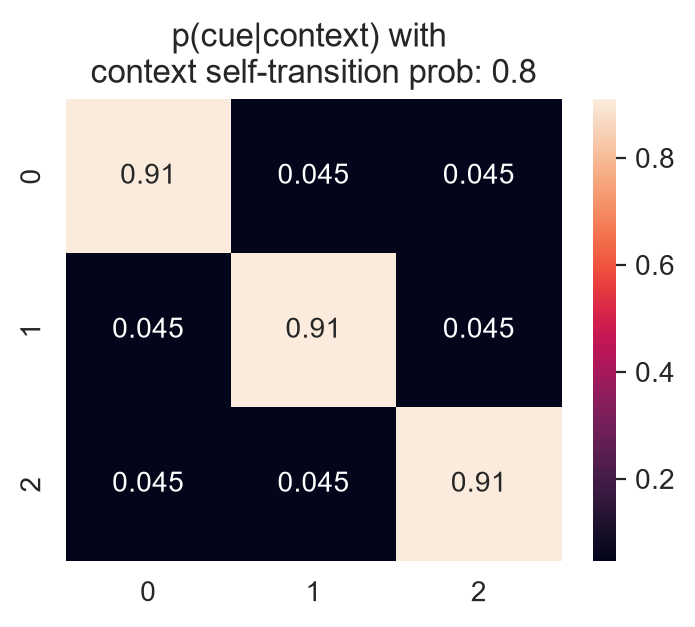

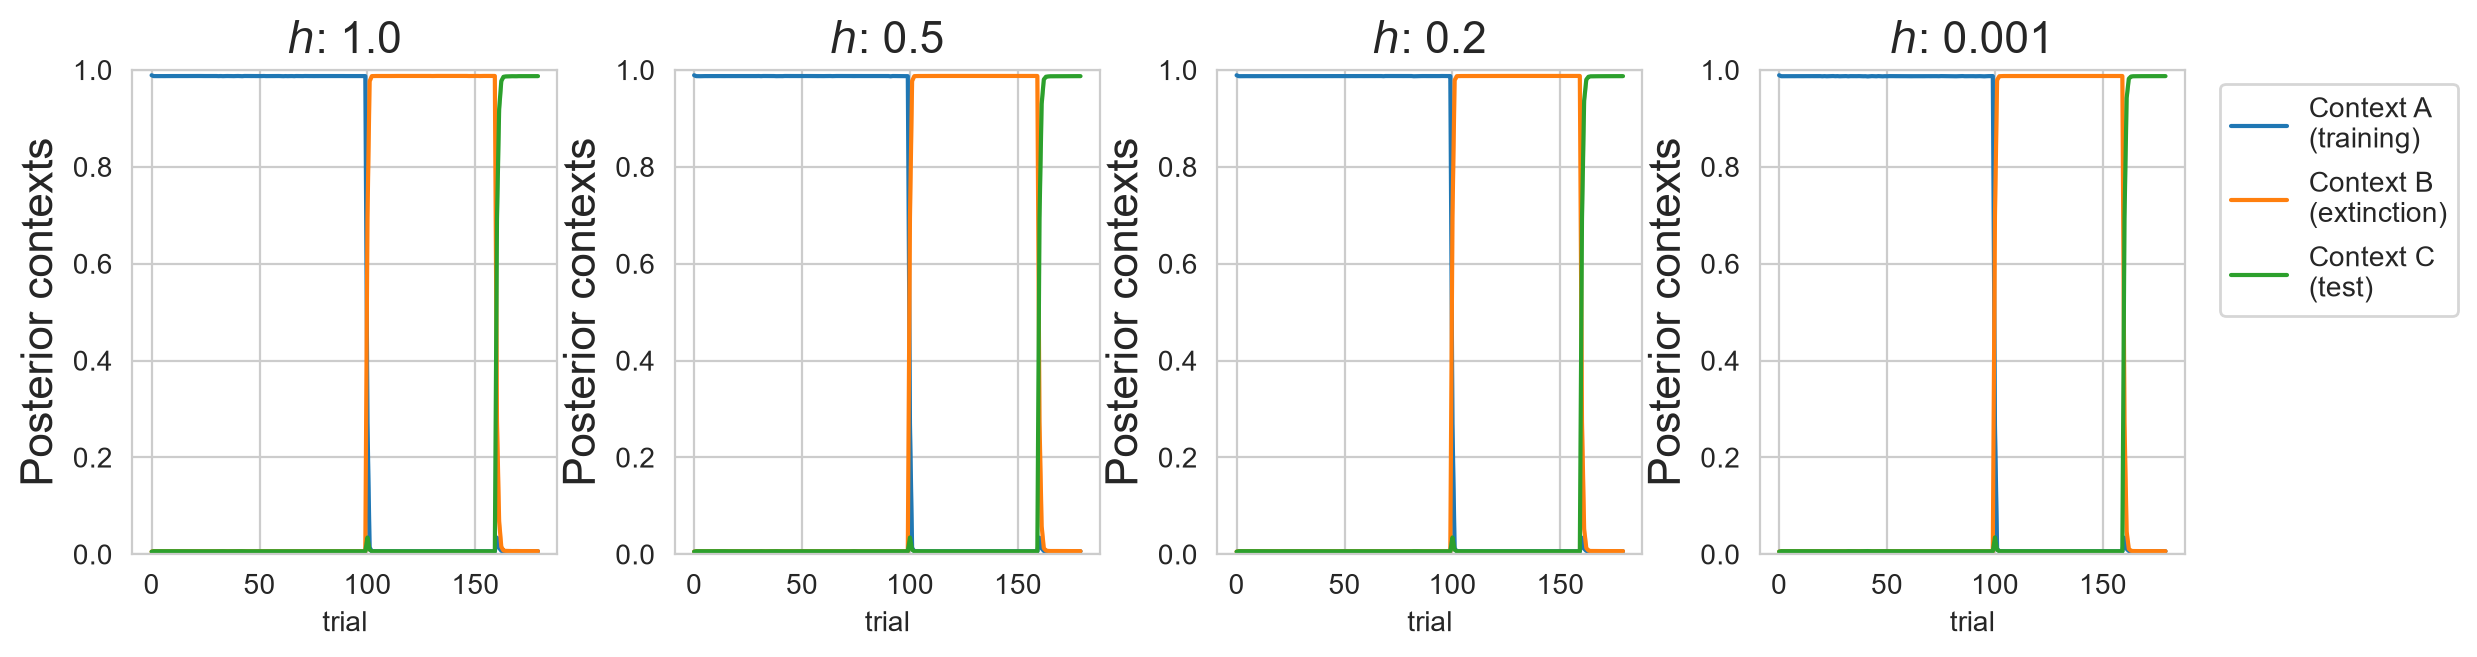

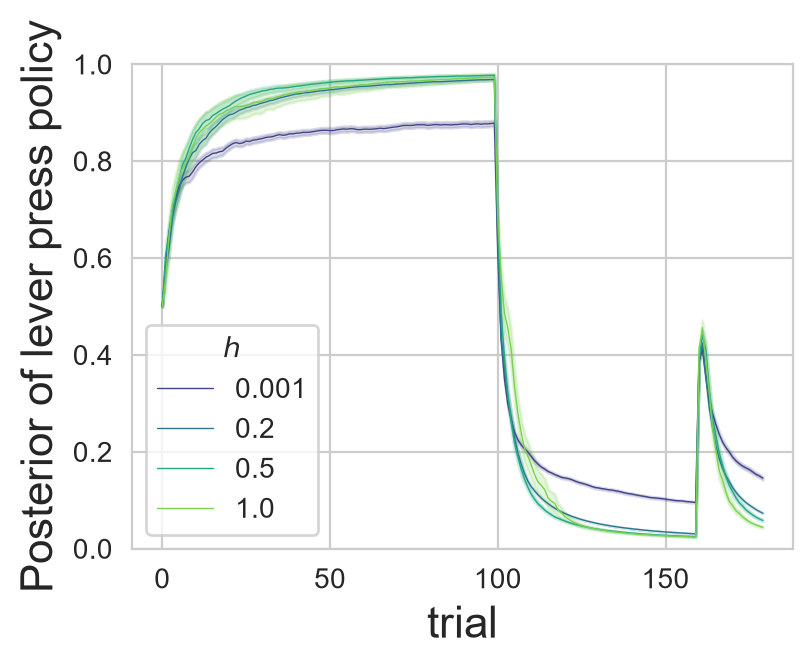

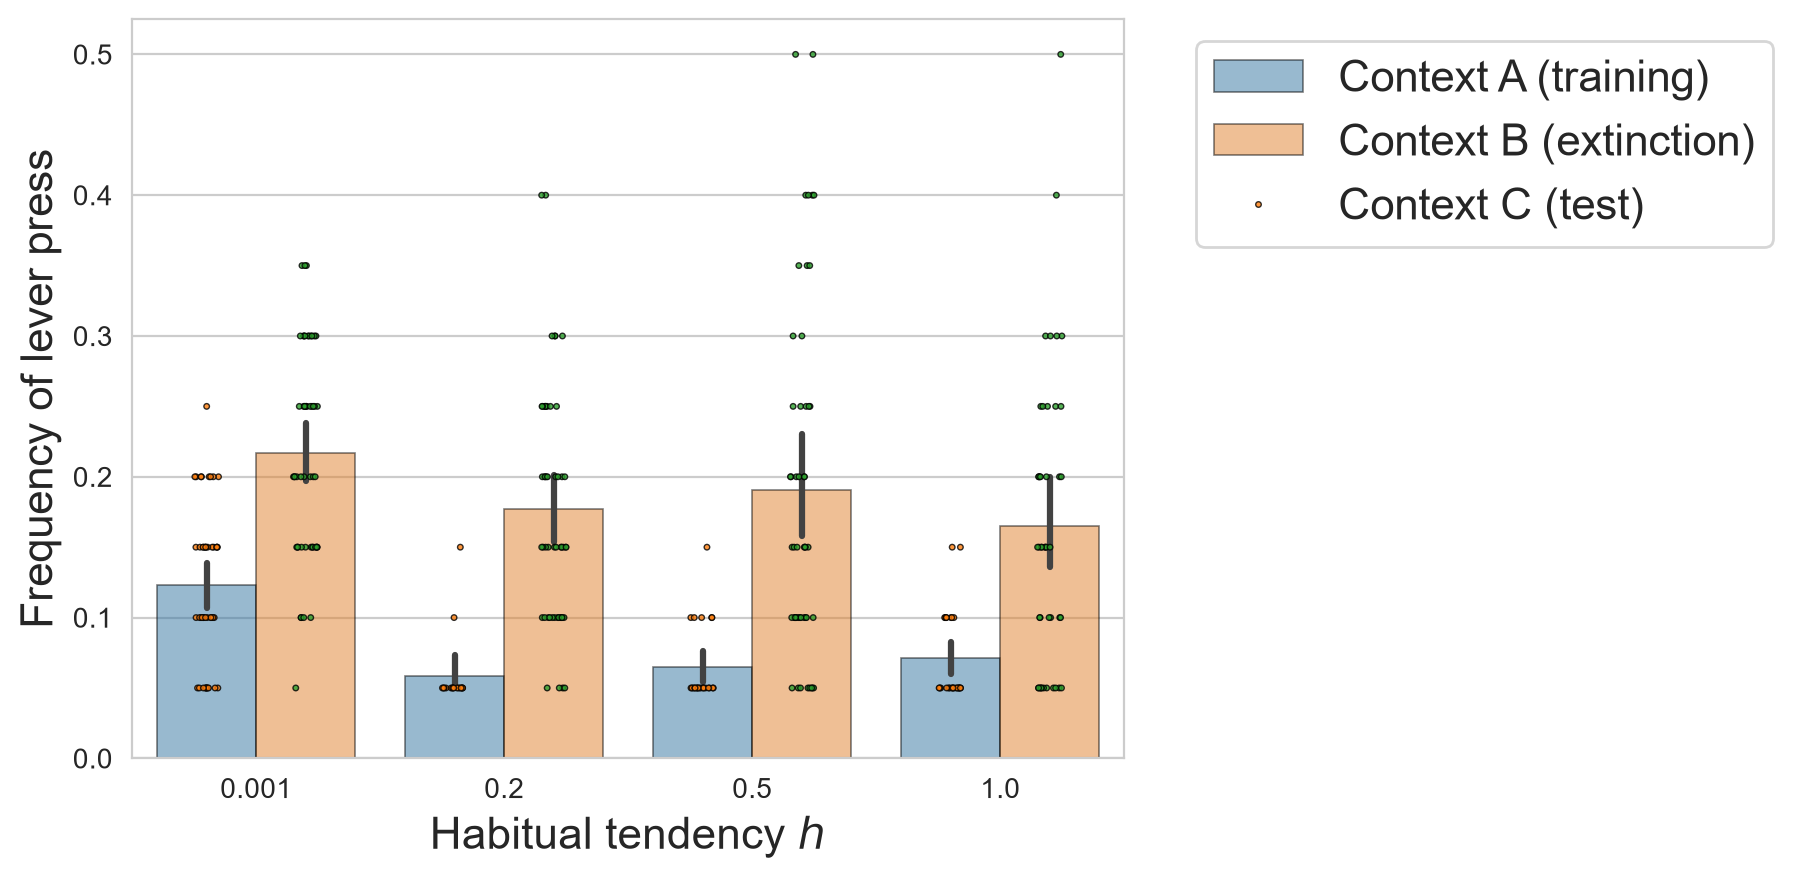

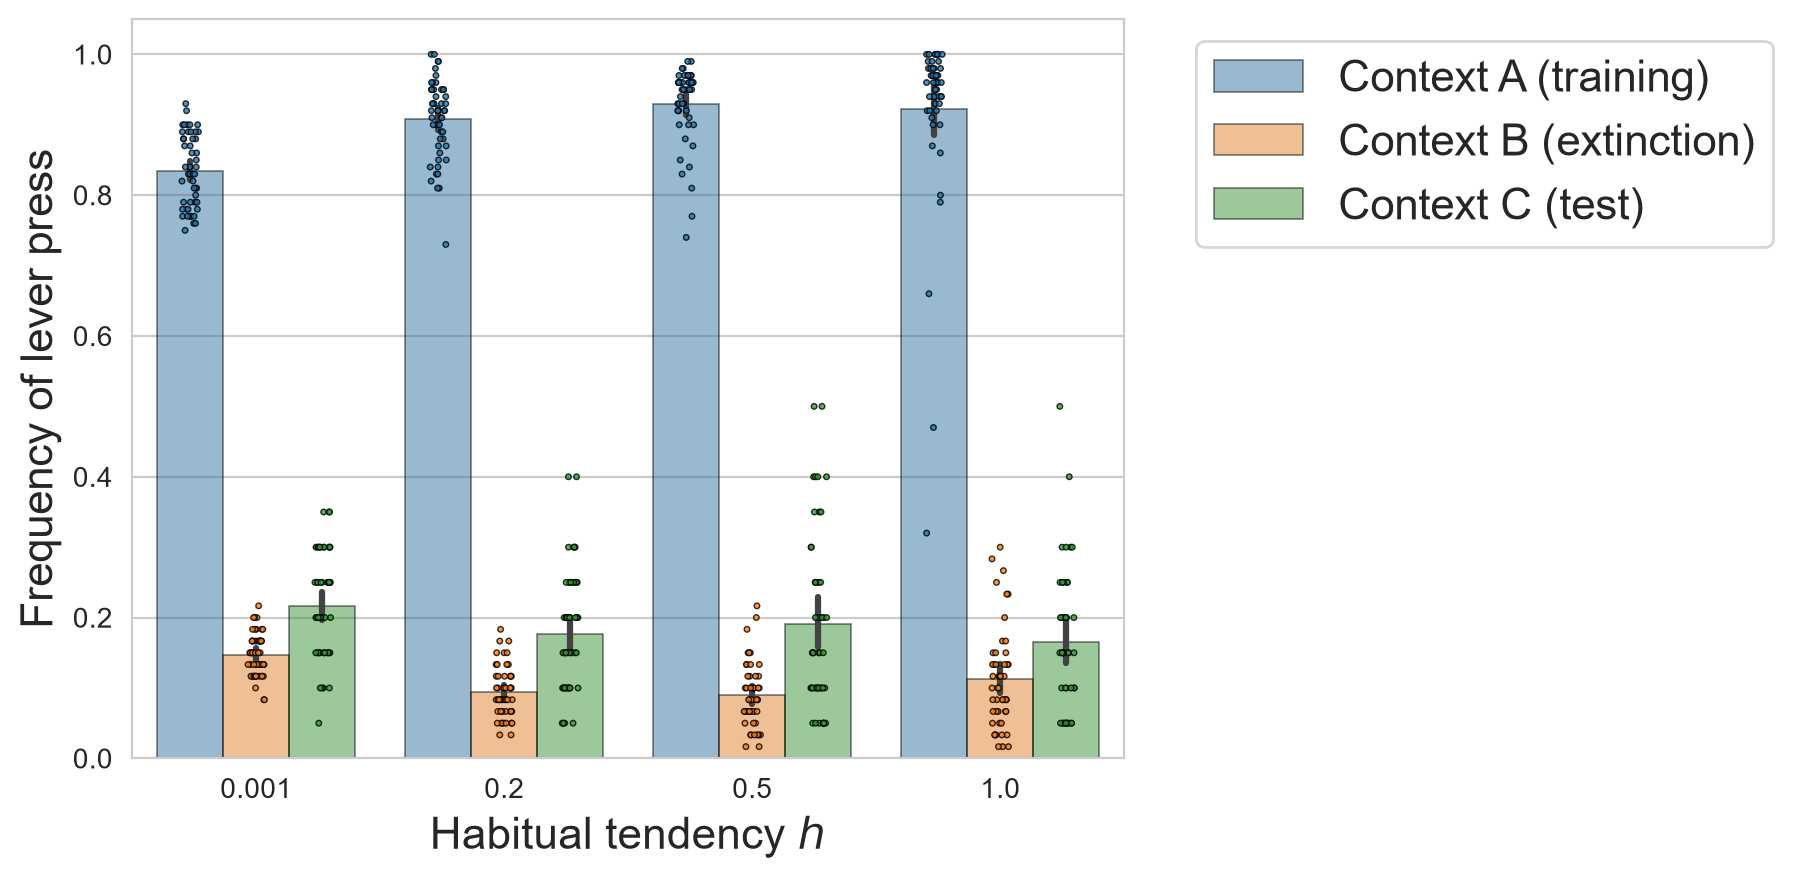

In [18]:
np.random.seed(7)
dpi = 200
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.8
trials_per_context = np.array([100,60,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[20,  1,  1],
                                [1,  20,  1],
                                [1,  1,   20]])
nsims= 50

name = "data_cue_reactivity_170_nonambiguous_certain"
# df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
#                                                    context_volatility=context_volatility, trials_per_context=trials_per_context,\
#                                                    nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


#### High volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.5
data_cue_reactivity_170_nonambiguous_certain_volatile


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


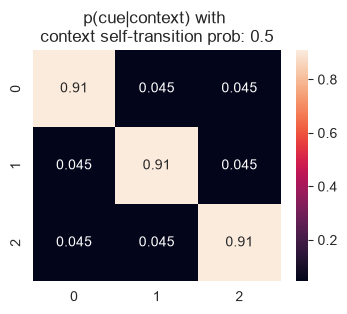

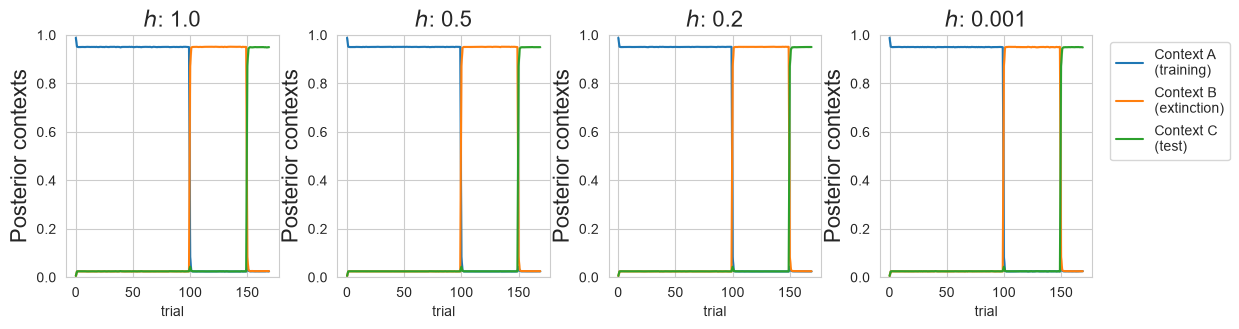

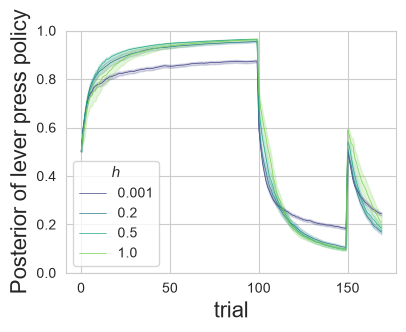

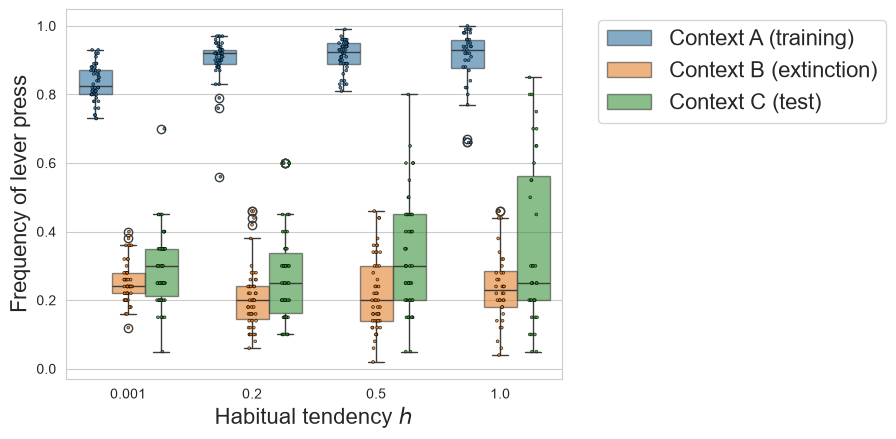

In [ ]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.5
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[20,  1,  1],
                                [1,  20,  1],
                                [1,  1,   20]])
nsims= 50

name = "data_cue_reactivity_170_nonambiguous_certain_volatile"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


### Ambiguous

#### Low volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.8
data_cue_reactivity_170_ambiguous_certain


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


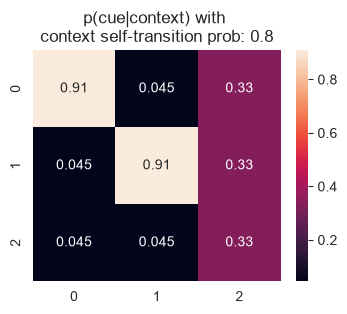

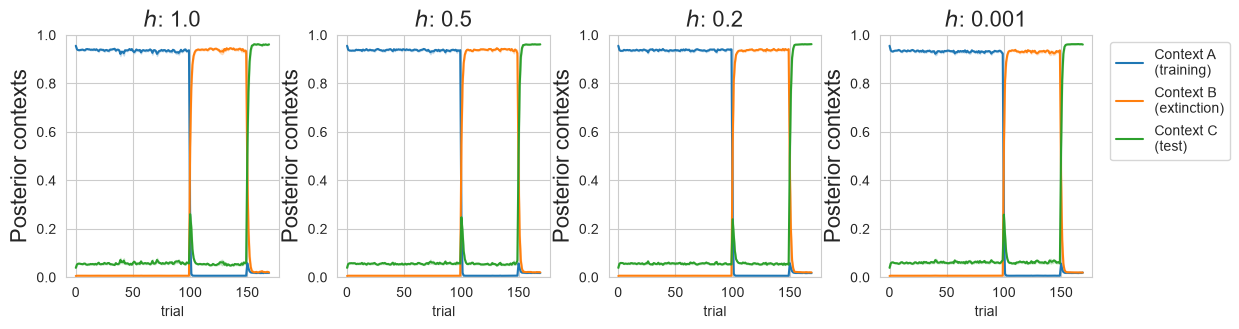

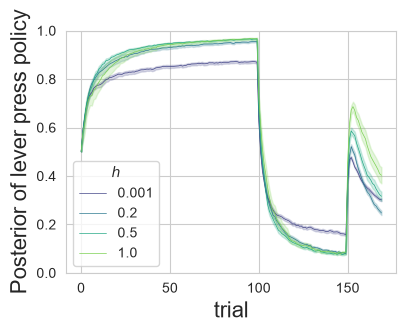

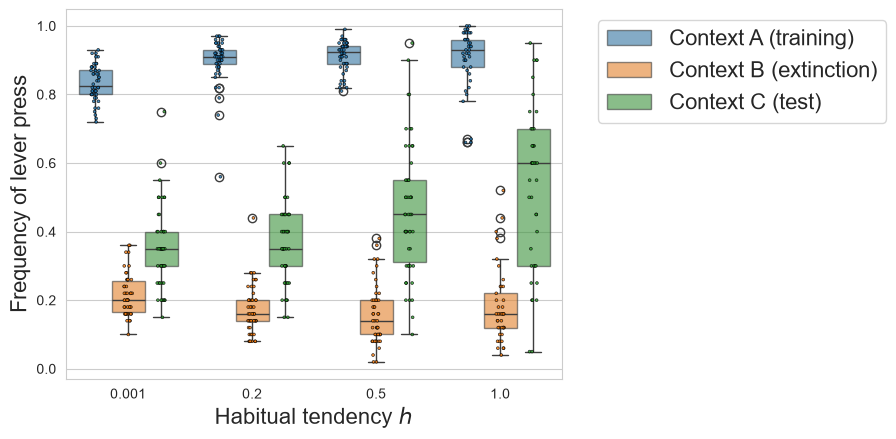

In [16]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.8
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[20,  1,  1],
                                [1,  20,  1],
                                [1,  1,   1]])
nsims= 50

name = "data_cue_reactivity_170_ambiguous_certain"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


#### High volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.5
data_cue_reactivity_170_ambiguous_certain_volatile


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


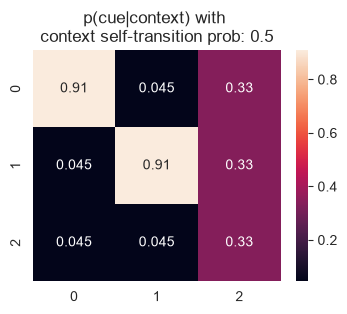

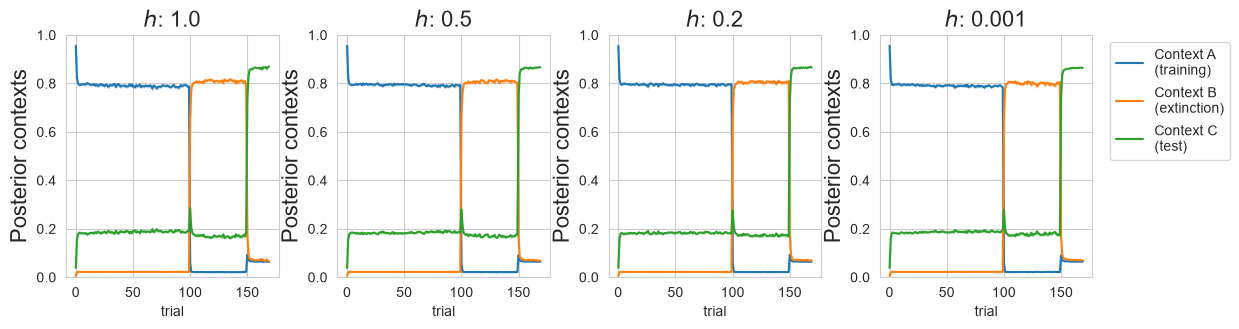

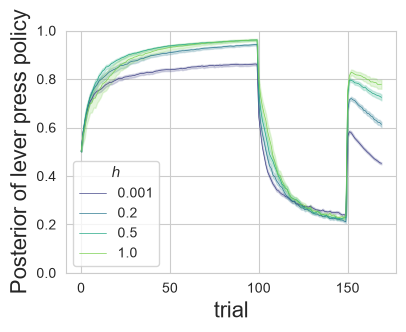

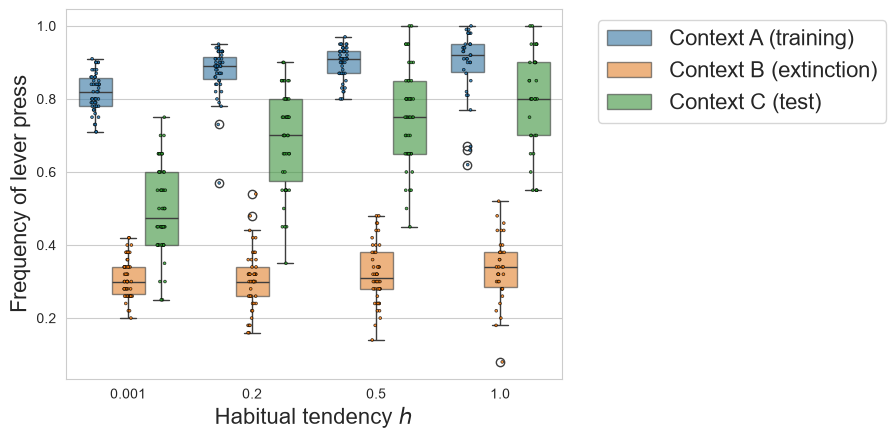

In [ ]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.5
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[20,  1,  1],
                                [1,  20,  1],
                                [1,  1,   1]])
nsims= 50

name = "data_cue_reactivity_170_ambiguous_certain_volatile"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


## Low certainty

### Non-ambiguous

#### Low volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.8
data_cue_reactivity_170_nonambiguous


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


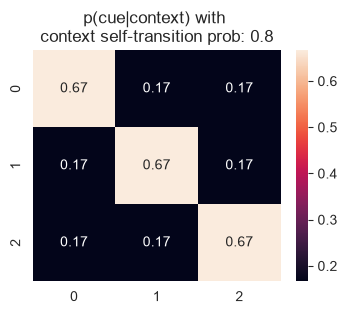

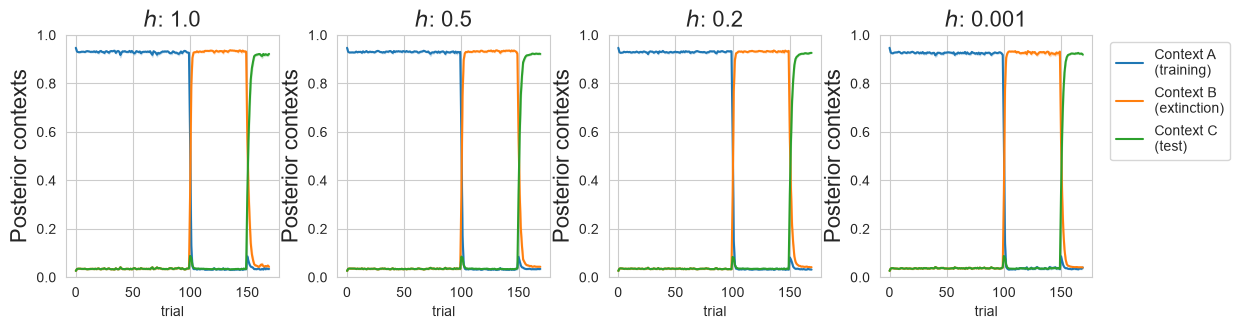

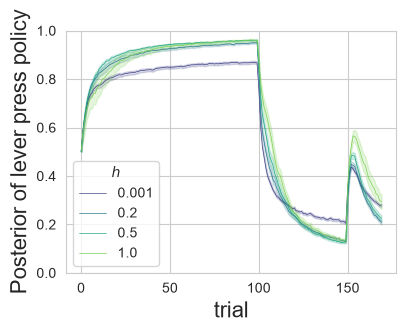

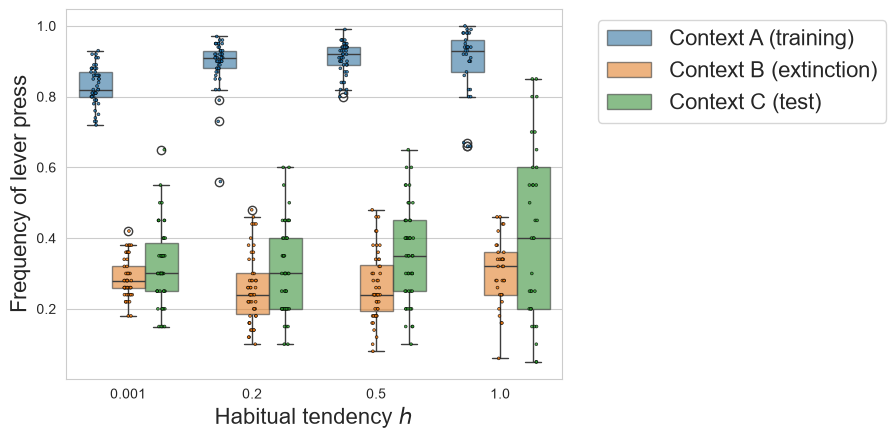

In [ ]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.8
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[4,  1,  1],
                                [1,  4,  1],
                                [1,  1,  4]])
nsims= 50

name = "data_cue_reactivity_170_nonambiguous"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


#### High volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.5
data_cue_reactivity_170_nonambiguous_volatile


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


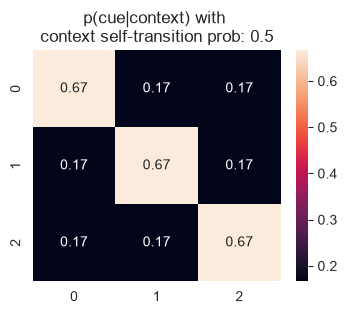

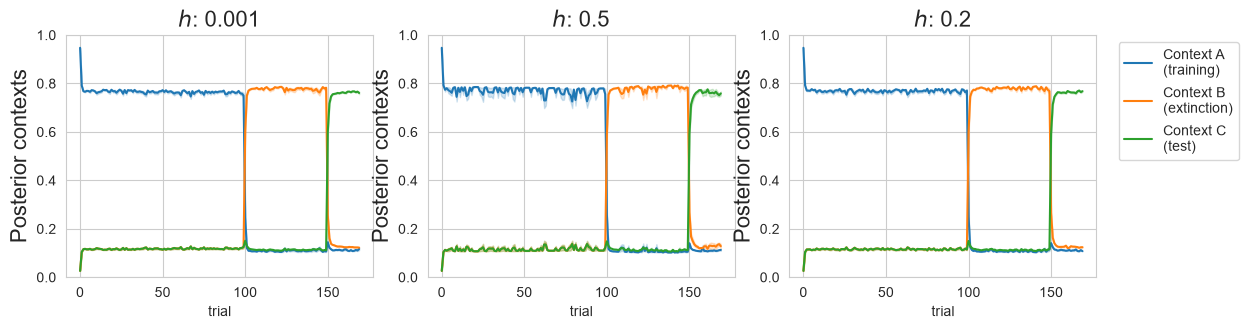

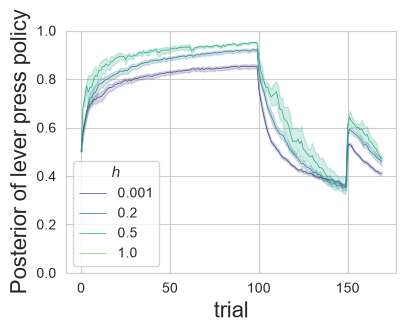

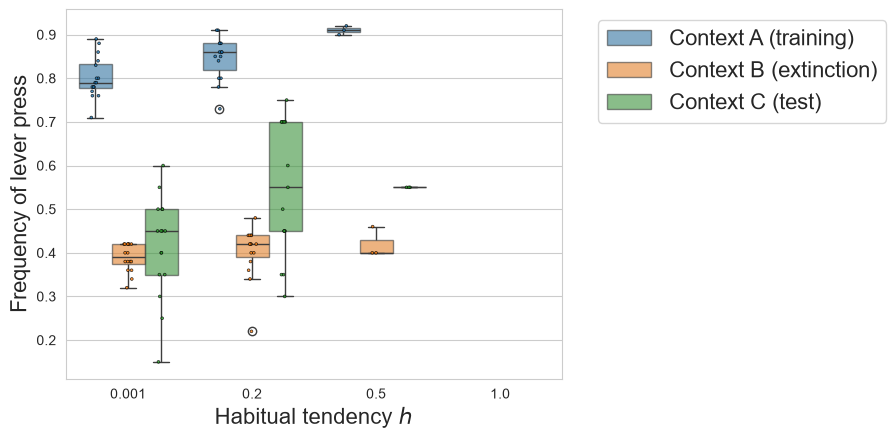

In [21]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.5
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[4,  1,  1],
                                [1,  4,  1],
                                [1,  1,  4]])
nsims= 50

name = "data_cue_reactivity_170_nonambiguous_volatile"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


### Ambiguous

#### Low volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.8
data_cue_reactivity_170_ambiguous


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


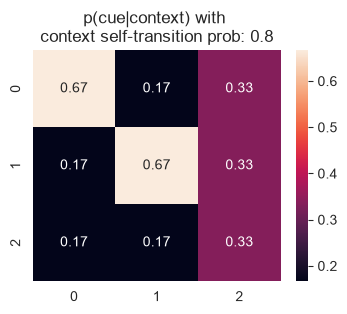

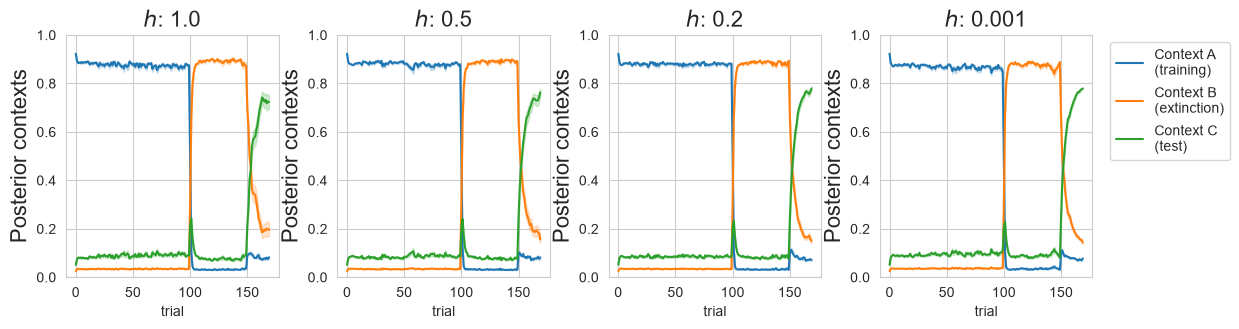

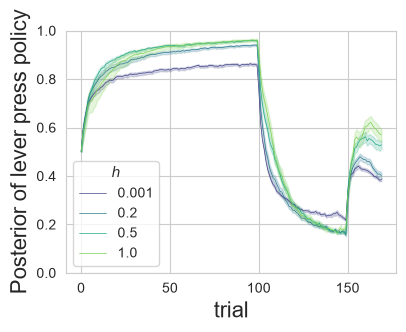

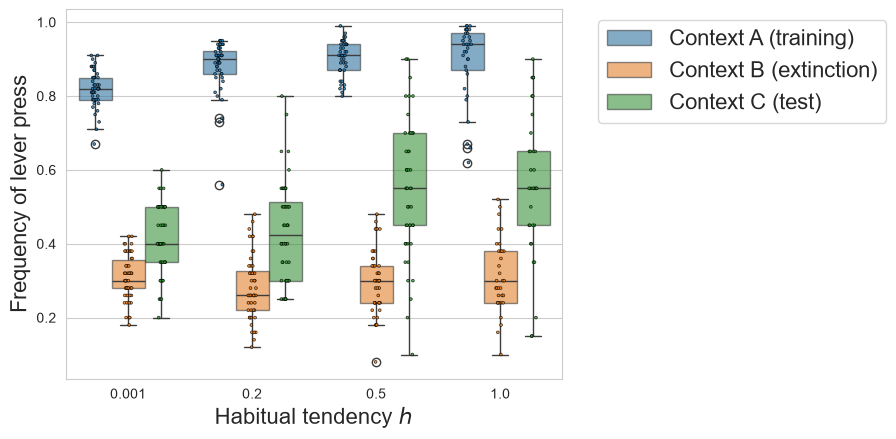

In [ ]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.8
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[4,  1,  1],
                                [1,  4,  1],
                                [1,  1,  1]])
nsims= 50

name = "data_cue_reactivity_170_ambiguous"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)


#### High volatility

simulations to run: 200
just finished sim 0
[0.025 0.95  0.025] 0.5
data_cue_reactivity_170_ambiguous_volatile


C:\Users\Admin\AppData\Local\Temp\ipykernel_14916\2273759382.py:1546: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 3
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context A (training)", "Context B (extinction)", "Context C (test)"], fontsize=16, title=None, bbox_to_anchor=(1.05, 1))


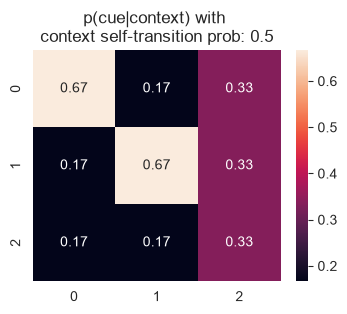

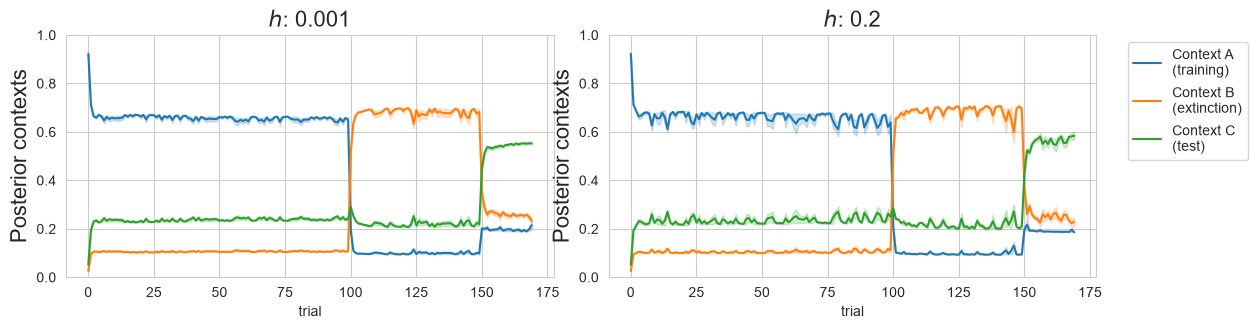

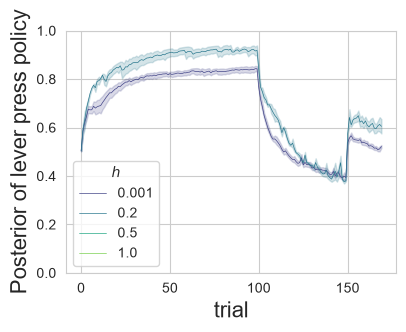

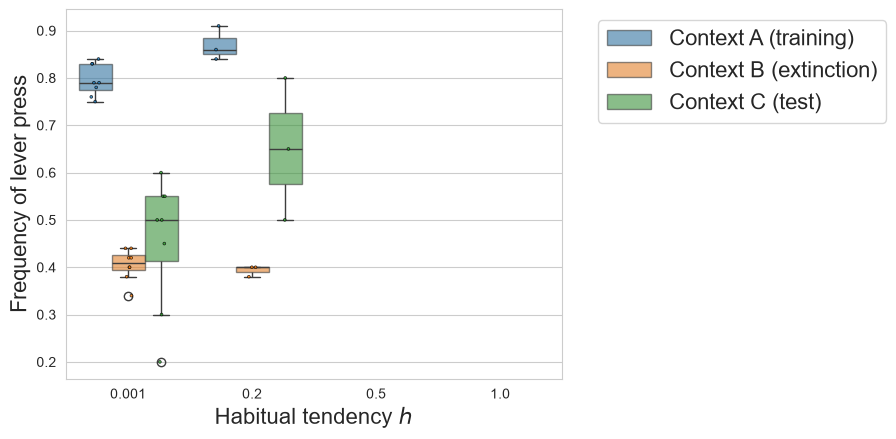

In [26]:
np.random.seed(7)
dpi = 100
hs = np.array([1,2,5,1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.5
trials_per_context = np.array([100,50,20])
p = 0
utility = np.array([0.025+p,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = False
if learn_cues:
    prior_color_cue = None
else:
	prior_color_cue = np.array([[4,  1,  1],
                                [1,  4,  1],
                                [1,  1,  1,]])
nsims= 50

name = "data_cue_reactivity_170_ambiguous_volatile"
df, df_long, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues)

df_long = pd.read_csv(name + "_long.csv")
df = pd.read_csv(name + ".csv")
plot_figures(df, df_long, prior_color_cue, dpi=dpi)
